## Research Report #2 for SOCIOL728

Dataset chosen: CielNet data from the \`networkdata\` package.

## I. Get Your Network: Data Description

The CielNet data are part of a study of criminal social networks carried out by Carlo Morselli. The Ciel Data consists of a small drug-importation network that was importing liquid hashish from Jamaica to Montreal. It was intercepted by Canadian authorities in 1996-97. Although a total of 75 people were surveiled as part of the investigation, the anonymous social network dataset contains 25 active members in the drug transportation network.

#### Motivation for Studying this Dataset:

The CielNet dataset contains crucial information within the size constraint of being small enough for a preliminary analysis as required by this assignment. The ties represent communication between various people involved in drug transportation, which presents an appropriate opportunity for social networks analysis. The data have been cleaned and anonymized, presented as an \`igraph\` object in R, making analysis convenient. According to author and researcher Carlo Morselli, this analysis helped test some assumptions in the field of criminal networks analysis that had been unchallenged earlier: scholars often over-estimated or under-estimated the necessity of having a strong organizational structure for criminal activity. It was easy to argue that criminals maintained a rigid hierarchy and reporting structure. It was also easy to assume that adversarial conditions and chaotic situations made such hierarchies fragile. Social networks analysis can measure centrality and hierarchy in such networks, providing evidence for their organizational structure.

#### Social Networks Concepts Relevant to this Dataset:

The dataset presents undirected ties for communication frequency between various members (nodes). Weights can be assigned to ties based on the frequency of communication. Measures of centrality and hierarchy will be important to reveal "leader" and "lieutenant" nodes, which were primary targets during the investigation by Montreal authorities. It would also be helpful to identify clusters or communities within this network in order to trace details in the organizational structure and possible flow of goods as well as information.

#### Code to Load Data and Prepare a Preliminary Visualization:

In [2]:
#setwd("/Users/ananyajogalekar/Library/CloudStorage/GoogleDrive-ananyajogalekar5@gmail.com/My Drive/Duke University/00-Coursework/SOCIOL728-SNA")

library(igraph)

In [3]:
#| message: false
# | warning: false
install.packages("drat")
drat::addRepo("schochastics")
install.packages("networkdata")


The downloaded binary packages are in
	/var/folders/yw/zr51wswj5pl5h03k4z3_qznr0000gn/T//RtmpM8Nr6T/downloaded_packages


Warning message:
“unable to access index for repository https://schochastics.github.io/drat/bin/macosx/big-sur-arm64/contrib/4.5:
  cannot open URL 'https://schochastics.github.io/drat/bin/macosx/big-sur-arm64/contrib/4.5/PACKAGES'”
installing the source package ‘networkdata’




Selecting the network of interest using its package: covert_12 for the CielNet data

In [4]:
ciel_data = networkdata::covert_12

This graph was created by an old(er) igraph version.
ℹ Call `igraph::upgrade_graph()` on it to use with the current igraph version.
For now we convert it on the fly...


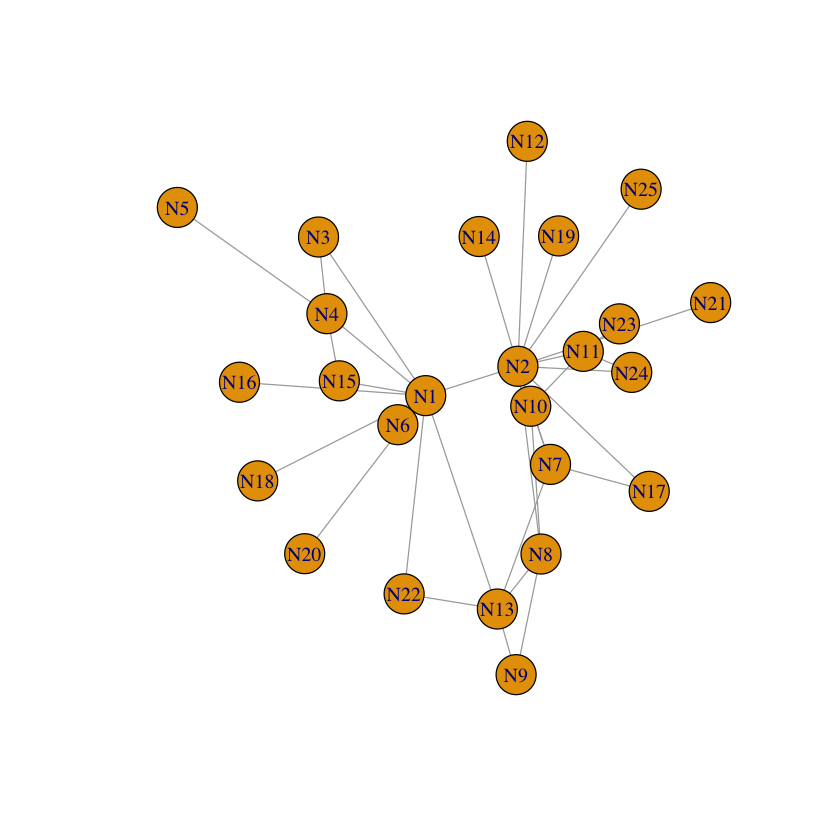

In [5]:
plot(ciel_data)

# II. Visualize the Network

Below is code for getting some useful measures and making better visualizations.

### Dyad and Triad Census

In [6]:
data("covert_12")

# Calculate Dyad Census
# For undirected graphs, this identifies "mut" (edges) and "null" (no edges)
dyad_results <- dyad_census(ciel_data)
print("Dyad Census:")
print(dyad_results)

# Calculate Triad Census
triad_results <- triad_census(ciel_data)
print("Triad Census:")
print(triad_results)

Warning message in data("covert_12"):
“data set ‘covert_12’ not found”
Warning message:
“`dyad_census()` requires a directed graph.”


[1] "Dyad Census:"
$mut
[1] 35

$asym
[1] 0

$null
[1] 265



Warning message in triad_census(ciel_data):
“At vendor/cigraph/src/misc/motifs.c:1157 : Triad census called on an undirected graph. All connections will be treated as mutual.”


[1] "Triad Census:"
 [1] 1643    0  518    0    0    0    0    0    0    0  130    0    0    0    0
[16]    9


### Inspecting the network

In [7]:
igraph::degree(ciel_data)
igraph::is.directed(ciel_data)
igraph::is.weighted(ciel_data)

N1  N2  N3  N4  N5  N6  N7  N8  N9 N10 N11 N12 N13 N14 N15 N16 N17 N18 N19 N20 
 10  12   2   4   1   1   4   4   2   4   4   1   5   1   2   1   2   1   1   1 
N21 N22 N23 N24 N25 
  1   2   1   2   1

Warning message:
“`is.directed()` was deprecated in igraph 2.0.0.
ℹ Please use `is_directed()` instead.”


[1] FALSE

Warning message:
“`is.weighted()` was deprecated in igraph 2.0.0.
ℹ Please use `is_weighted()` instead.”


[1] TRUE

We see that the network is undirected and weighted. So we should inspect the weights.

In [8]:
igraph::E(ciel_data)$weight
summary(igraph::E(ciel_data)$weight)

[1] 21  1  4 17  1  3  1  1  1  1  5  1 22 15  1  2  1  2  1  1  1  1  1  1  1
[26]  1  1  1  1  2  9  1 20 10  1

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     1.0     1.0     4.4     3.5    22.0 

These weights seem to represent the strength of ties, i.e. frequency of communication among members of the network.

### Measures of Centrality and Hierarchy

We create distance weights (for shortest paths):

In [9]:
dist_weights <- 1 / igraph::E(ciel_data)$weight

Centrality Measures:

In [10]:
strength_vals <- igraph::strength(ciel_data)

bet_vals <- igraph::betweenness(
  ciel_data,
  weights = dist_weights,
  normalized = TRUE
)

clo_vals <- igraph::closeness(
  ciel_data,
  weights = dist_weights,
  normalized = TRUE
)

eig_vals <- igraph::eigen_centrality(
  ciel_data,
  weights = igraph::E(ciel_data)$weight
)$vector

In [11]:
centrality_table <- data.frame(
  strength = strength_vals,
  betweenness = bet_vals,
  closeness = clo_vals,
  eigenvector = eig_vals
)

centrality_table

,strength,betweenness,closeness,eigenvector
,<dbl>,<dbl>,<dbl>,<dbl>
N1,51,0.670289855,1.4798582,0.699161010
N2,73,0.717391304,1.4842162,1.000000000
N3,2,0.000000000,0.6198704,0.020154880
N4,7,0.083333333,1.1311273,0.074869892
N5,1,0.000000000,0.5427682,0.001949526
N6,17,0.000000000,1.3659094,0.309491017
N7,8,0.007246377,1.1955220,0.147130748
N8,5,0.000000000,0.6764024,0.043078148
N9,10,0.000000000,0.6498699,0.007329527


### Hierarchy Measures:

Degree Centralization:

In [12]:
strength_vals <- igraph::strength(ciel_data)

In [13]:
max_strength <- max(strength_vals)
n <- igraph::vcount(ciel_data)

centralization_strength <-
  sum(max_strength - strength_vals) /
  ((n - 1) * (n - 2))   # normalization for undirected network

centralization_strength

[1] 2.748188

Weighted Betweenness Centralization:

In [14]:
dist_weights <- 1 / igraph::E(ciel_data)$weight

bet_vals <- igraph::betweenness(
  ciel_data,
  weights = dist_weights,
  normalized = FALSE
)

max_bet <- max(bet_vals)

centralization_bet <-
  sum(max_bet - bet_vals) /
  ((n - 1) * (n - 2) * (n - 3) / 2)

centralization_bet

[1] 0.7366601

Weighted Closeness Centralization:

In [15]:
clo_vals <- igraph::closeness(
  ciel_data,
  weights = dist_weights,
  normalized = FALSE
)

max_clo <- max(clo_vals)

centralization_clo <-
  sum(max_clo - clo_vals) /
  ((n - 1) * (n - 2) / (2*n - 3))

centralization_clo

[1] 0.05071381

# Visualizations

Show Tie Strength with Edge Width + Node Strength Size:

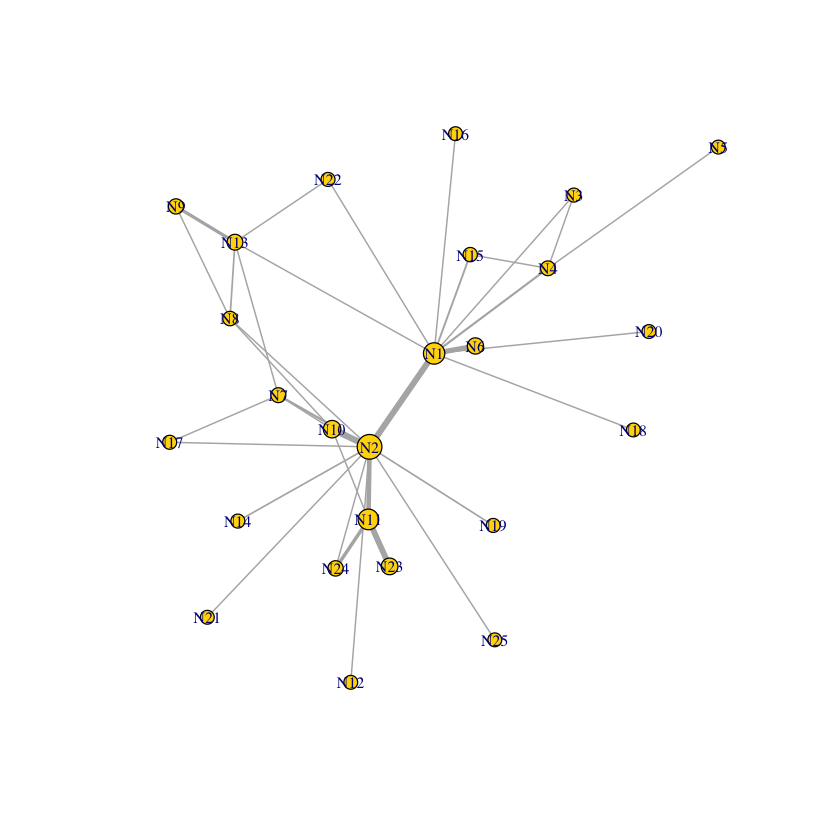

In [16]:
g <- ciel_data

# Node strength (weighted degree)
V(g)$strength <- strength(g)

# Scale node size
V(g)$size <- 5 + 4 * (V(g)$strength / max(V(g)$strength))

# Scale edge width by weight
E(g)$width <- 1 + 4 * (E(g)$weight / max(E(g)$weight))

# Light gray edges
E(g)$color <- "gray70"

# Use Fruchterman-Reingold layout
set.seed(123)
plot(g,
     layout = layout_with_fr(g),
     vertex.label.cex = 0.8,
     vertex.color = "gold")

Detect and Color Communities:

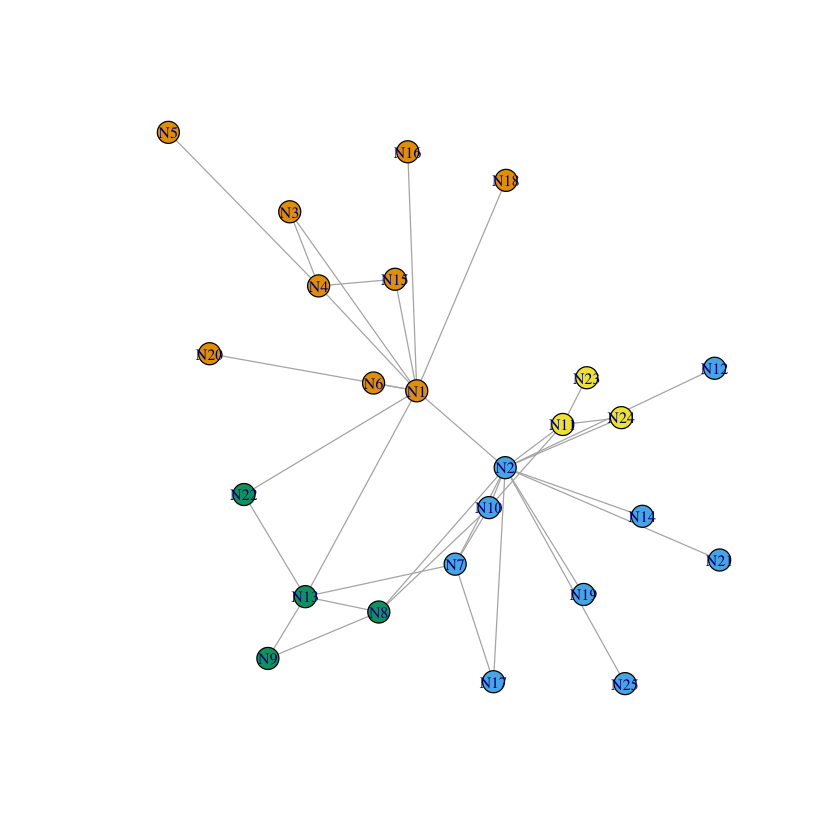

In [17]:
# Community detection (Louvain works well for weighted networks)
comm <- cluster_louvain(g, weights = E(g)$weight)

V(g)$color <- membership(comm)

plot(g,
     layout = layout_with_fr(g),
     vertex.size = 8,
     vertex.label.cex = 0.8,
     edge.width = 1)

Combine Strength + Community + Tie Strength:

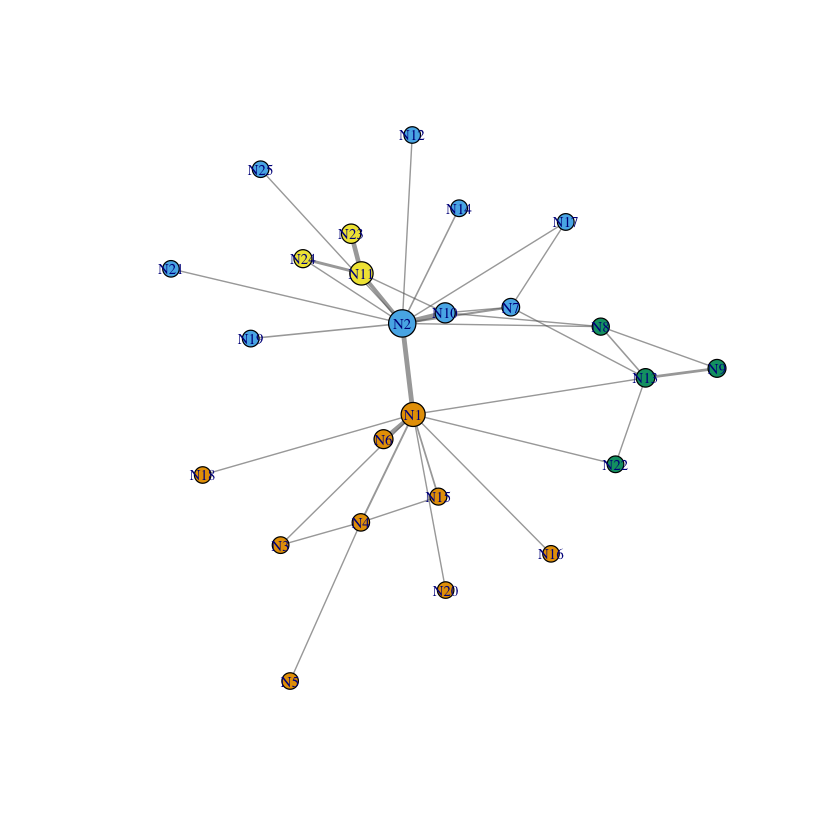

In [18]:
g <- ciel_data

# Strength for size
V(g)$size <- 6 + 4 * (strength(g) / max(strength(g)))

# Community for color
comm <- cluster_louvain(g, weights = E(g)$weight)
V(g)$color <- membership(comm)

# Edge width by weight
E(g)$width <- 1 + 3 * (E(g)$weight / max(E(g)$weight))
E(g)$color <- adjustcolor("gray40", alpha.f = 0.6)

plot(g,
     layout = layout_with_fr(g),
     vertex.label.cex = 0.75)

### Trying to Detect Communities

In [19]:
g <- ciel_data
comm <- cluster_louvain(g)  
membership <- membership(comm)

In [20]:
# Generate a color palette
library(RColorBrewer)
colors <- brewer.pal(max(membership), "Set3")  # adjust for number of communities

V(g)$color <- colors[membership]

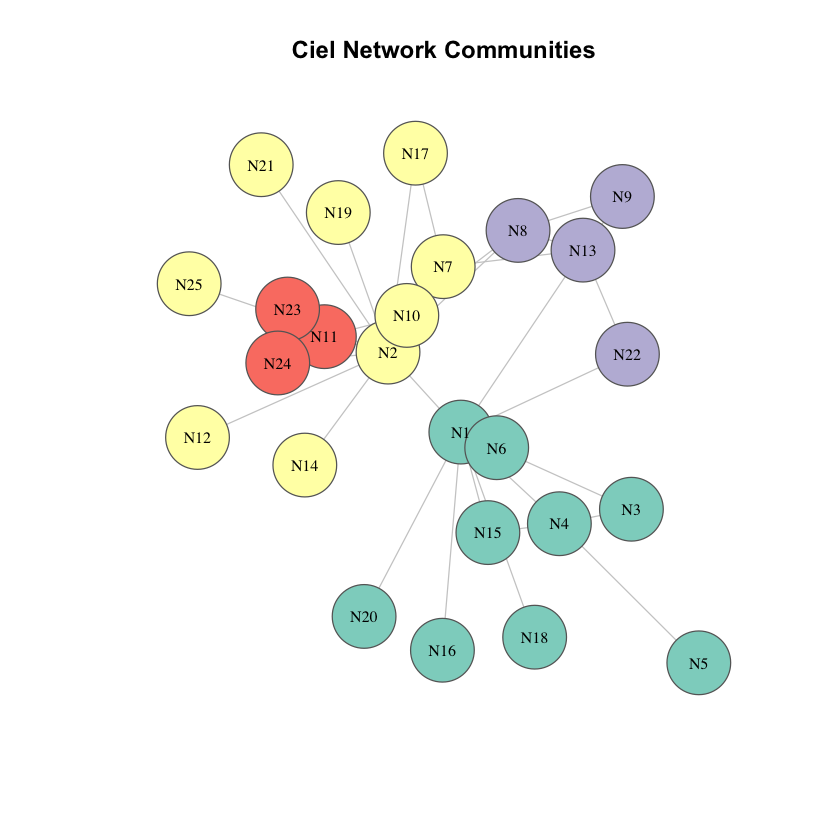

In [22]:
plot(
  g,
  vertex.size = 25,
  vertex.label.cex = 0.8,
  vertex.label.color = "black",
  vertex.frame.color = "gray40",
  edge.color = "gray80",
  layout = layout_with_fr,  # force-directed layout
  main = "Ciel Network Communities"
)

Trying out the `ggraph` library:

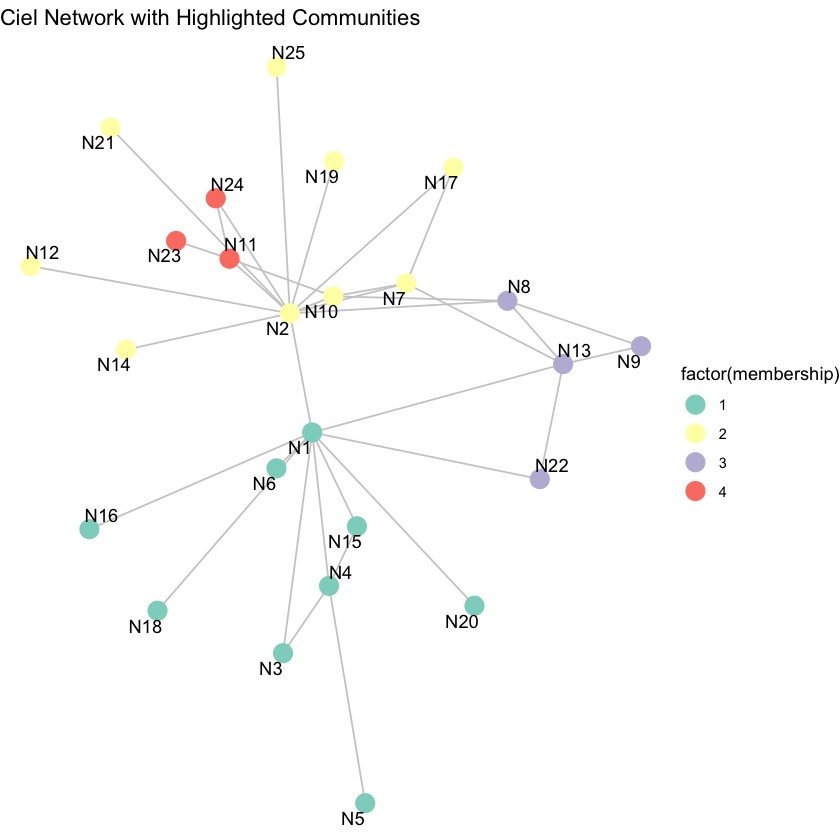

In [24]:
library(ggraph)
library(tidygraph)
g_tbl <- as_tbl_graph(g)

ggraph(g_tbl, layout = "fr") +
  geom_edge_link(color = "grey80") +
  geom_node_point(aes(color = factor(membership)), size = 5) +
  geom_node_text(aes(label = name), repel = TRUE) +
  scale_color_brewer(palette = "Set3") +
  theme_void() +
  ggtitle("Ciel Network with Highlighted Communities")

# III. Interpret the Structure

1.  Centrality Measures:

    Based on tie strength and the structure of the network, we can infer strong centrality. Nodes N1 and N2 have a high degree of centrality as well as maintain strong communication among themselves. The network can be roughly divided into 2 subsets, each connected closely to either N1 or N2. The centrality scores for centrality, betweenness etc are also very high for N1 and N2 and very low for all other nodes in the network. This indicates a concentration of communication in N1 and N2. This is very useful for identifying N1 and N2 as possible "leaders" and/or "lieutenants" in this criminal network, controlling the flow of information, influencing decisions, and possibly controlling the flow of goods and funds, too.

2.  Hierarchy Measures:

    The above interpretation continues to hold for hierarchy measures (centralization on the network level instead of on the level of individual nodes). High strength centralization (2.75) indicates unequal strength of communication in the network, while high betweenness centralization (0.74) suggests that some nodes act as important brokers, making others depend on them for communication. Closeness centralization is relatively low (0.5), which suggests that not everyone in the network is equally clsoely connected to each other. All of these measures point at low overall accessibility, indicating a stronger hierarchy where a few nodes control most communications.

3.  Community Clusters:

    Identifying and visualizing communities within this small network further reinforces the above findings. Around two-thirds of all members get classified into communities clustered around one of the central members (N1 or N2). Two smaller communities are of two types: a few members connected to both N1 and N2, and a sub-community of 3 members closely connected to each other but embedded in a larger community around N2.

4.  Overall Interpretation:

    Taken together, the centrality, hierarchy, and community analyses consistently indicate a highly concentrated and broker-driven network structure. Communication and interaction are strongly centered around N1 and N2, who dominate both in terms of tie strength and structural position. The high strength and betweenness centralization values show that interaction volume and control over communication flows are unevenly distributed, with most members depending on a small number of central actors. At the same time, the relatively low closeness centralization suggests that while many actors can reach each other indirectly, this reachability is largely mediated through the central figures rather than being evenly distributed across the network.

    The community structure further reinforces this pattern. Most actors are embedded in clusters organized around either N1 or N2, indicating two dominant spheres of influence within the broader network. Smaller subgroups either bridge between these two central actors or form tightly connected pockets within one sphere of influence. Overall, the network exhibits a broker-centered hierarchy in which a few key individuals concentrate communication, coordination, and likely decision-making power, while the remaining members occupy more peripheral and dependent positions.


# ----- RESEARCH REPORT 1 CONTENT ENDS HERE -----

## Report 2 Ideas Brainstorming

1. Is a low degree or a degree of 1 on nodes a bug or a feature? Are they simply peripheral nodes or are *some* of them actually the bosses, isolated from everyone else for protection?
    - Checking the frequency of comms for low-degree nodes could illuminate this. If someone among them has an unusually high weight i.e. tie strength (representing frequency of comms), they're likely an important person, and their degree of 1 is actually a protection for their position.
    - For this report, a "low" degree would correspond to a degree of 2 or less.
    - For 2-degree nodes, I can try computing average tie strength across all ties to consider as the key metric.


2. Can I run an ERGM to whether the observed structure is consistent with theoretically expected properties of covert criminal networks (hub formation, transitivity, sparse density)? This relates to the data's credibility as in indirect measure of how much noise could be present in the data. Given that these data were collected with wiretap messages and the overall context of covert crime investigation, there is a high chance of data getting corrupted or incorrect data being collected for various reasons.
    - If Morselli / the government are estimated to have collected good data that likely matches the actual network, the policy recommendations generated by studying these data would likely be highly effective in the real world.


3. Can I simulate various policy interventions that can be used to intercept or dismantle this criminal network? The success of these simulations can directly inform action recommendations.
    - It's possible to simulate how the network dismantles when key nodes are removed one by one.
    - I could test various policies for removing nodes: 
        3.1. highest-degree-first
        3.2. lowest-degree-first
        3.3. random
        3.4. manual targeting: choosing specific nodes manually and then others at random
        3.5. recalculated centrality targeting: after each node removal, recompute centrality on the residual network before choosing the next target
    
    - The policies tested here can be based upon the results of the earlier 2 analyses:
        -  If in Step 1 I find that some low-degree nodes have a high weight of communication strength, removing those nodes first should give worse-than-random outcomes and cause the network to collapse to a greater extent.
        - If the ERGM in Step 2 shows that the data matches a real-world distribution, testing various policies here would augment those inferential results with action suggestions.

A caveat about sample size: 25 is a small sample size for an ERGM, although other methods should work well with it. So, the internal validity of the ERGM can be challenged. I will address this by having fewer terms in the ERGM configuration, but even so, this is a methodological limitation that can be mitigated by gathering more data. In domains like criminology, obtaining data can be a serious challenge, so it is important to work with the available data and produce results to the best of our ability.


# Analysis 1: Low-Degree Nodes and Tie Strength
Key Question: Is low degree a signal of low importance or a security mask for highly important members?

**1.1. Setup and filtering**

In [1]:
library(igraph)
library(ggplot2)
library(ggraph)
library(tidygraph)
library(dplyr)

# Load data
g <- networkdata::covert_12

# Compute degree for all nodes
deg <- igraph::degree(g)

# Identify low-degree nodes (degree <= 2)
low_deg_nodes <- names(deg[deg <= 2])
low_deg_nodes


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


This graph was created by an old(er) igraph version.
ℹ Call `igraph::upgrade_graph()` on it to use with the current igraph version.
For now we convert it on the fly...


[1] "N3"  "N5"  "N6"  "N9"  "N12" "N14" "N15" "N16" "N17" "N18" "N19" "N20"
[13] "N21" "N22" "N23" "N24" "N25"

**1.2. Compute tie strength metrics**

In [2]:
# Raw strength (sum of edge weights) for all nodes
raw_strength <- igraph::strength(g)

# Average tie intensity (strength / degree) for all nodes
avg_intensity <- raw_strength / deg

# Build summary table for low-degree nodes only
summary_table <- data.frame(
  Node             = low_deg_nodes,
  Degree           = deg[low_deg_nodes],
  Raw_Strength     = raw_strength[low_deg_nodes],
  Avg_Intensity    = avg_intensity[low_deg_nodes],
  row.names        = NULL
)

summary_table

Node,Degree,Raw_Strength,Avg_Intensity
<chr>,<dbl>,<dbl>,<dbl>
N3,2,2,1.0
N5,1,1,1.0
N6,1,17,17.0
N9,2,10,5.0
N12,1,1,1.0
N14,1,2,2.0
N15,2,4,2.0
N16,1,1,1.0
N17,2,2,1.0


Based on this table, we see that some low-degree nodes have oddly high tie strengths! These are N23 (average strength of 20), N6 (17), N24 (5.5), and N9 (5). It's possible that these nodes are structurally different from the majority of low-degree nodes which have low tie strengths. These nodes could actually be **hidden importants:** important members of the criminal network who are being protected from vulnerable exposure, hence have a low degree of members they are connected to, but wield high power and access to information through strong ties.

**1.3. Flag potential hidden importants**

First, I check which nodes lie significantly above the mean level of average intensity in the group of low-degree nodes. This is a standard statistical cutoff for defining the tie strength required to become a hidden important.

In [ ]:
# --- Statistical threshold: 1 SD above the group mean of average intensity ---
group_mean <- mean(summary_table$Avg_Intensity)
group_sd   <- sd(summary_table$Avg_Intensity)
stat_cutoff <- group_mean + group_sd

summary_table$Flag_Statistical <- ifelse(
  summary_table$Avg_Intensity > stat_cutoff, "high", "typical"
)

Statistical threshold (mean + 1 SD): 9.486 


Next, I incorporate manual insights from the table genereated in step 1.2, where the nodes I observed to be oddly important had an average intensity of 5 or above. Hence, I set a manual threshold of 4.9 for considering nodes to be hidden importants, and store those results alongside the results from the statistical threshold.

This will allow me to compare whether the manual cutoff causes any difference to the final results of this analysis, and make room for a more sensible choice of the threshold.

In [ ]:
# Print the cutoff so you know what value it landed on
cat("Statistical threshold (mean + 1 SD):", round(stat_cutoff, 3), "\n")

# --- Manual threshold: based on the table, we can choose a cutoff of 4.9 ---
manual_cutoff <- 4.9

summary_table$Flag_Manual <- ifelse(
  summary_table$Avg_Intensity > manual_cutoff, "high", "typical"
)

In [7]:
summary_table

Node,Degree,Raw_Strength,Avg_Intensity,Flag_Statistical,Flag_Manual
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
N3,2,2,1.0,typical,typical
N5,1,1,1.0,typical,typical
N6,1,17,17.0,high,high
N9,2,10,5.0,typical,high
N12,1,1,1.0,typical,typical
N14,1,2,2.0,typical,typical
N15,2,4,2.0,typical,typical
N16,1,1,1.0,typical,typical
N17,2,2,1.0,typical,typical


**1.4. Visualization of Results**

1.4.1. Bar chart of average tie intensity 

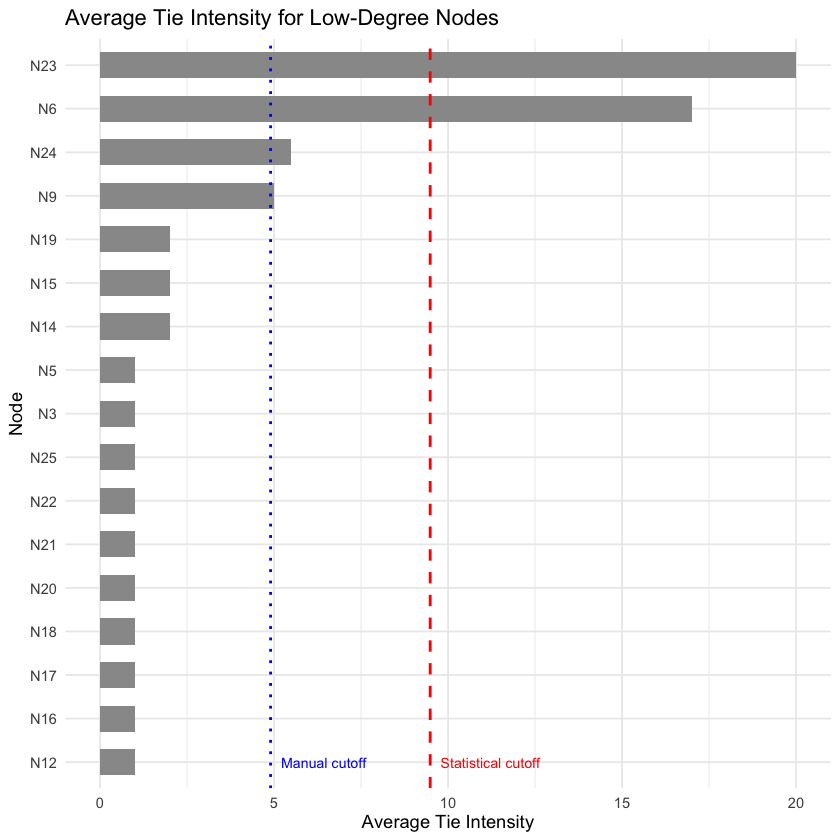

In [17]:
ggplot(summary_table, aes(x = reorder(Node, Avg_Intensity), y = Avg_Intensity)) +
  geom_col(width = 0.6, fill="grey60") +
  geom_hline(yintercept = stat_cutoff, linetype = "dashed", color = "red",
             linewidth = 0.8) +
  geom_hline(yintercept = manual_cutoff, linetype = "dotted", color = "blue",
             linewidth = 0.8) +
  annotate("text", x = 1, y = stat_cutoff + 0.3,
           label = "Statistical cutoff", color = "red", hjust = 0, size = 3) +
  annotate("text", x = 1, y = manual_cutoff + 0.3,
           label = "Manual cutoff", color = "blue", hjust = 0, size = 3) +
  coord_flip() +
  labs(
    title = "Average Tie Intensity for Low-Degree Nodes",
    x = "Node", y = "Average Tie Intensity"
  ) +
  theme_minimal()

1.4.2. Network plot with low-degree nodes highlighted

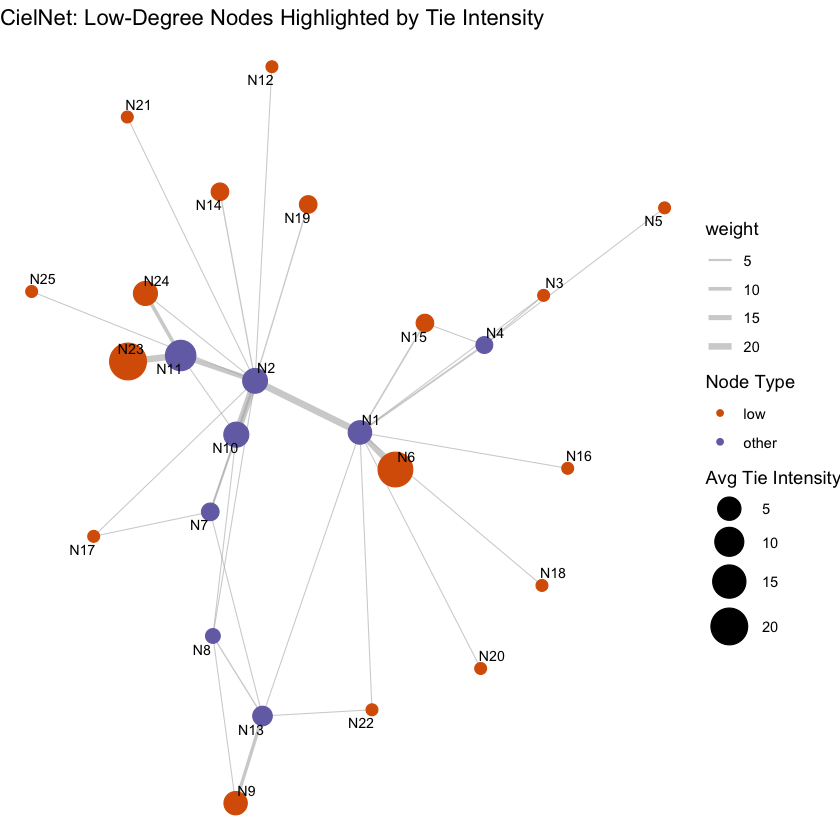

In [5]:
# Add node-level attributes to the graph for plotting
V(g)$is_low_deg    <- ifelse(V(g)$name %in% low_deg_nodes, "low", "other")
V(g)$avg_intensity <- avg_intensity[V(g)$name]

g_tbl <- as_tbl_graph(g)

ggraph(g_tbl, layout = "fr") +
  geom_edge_link(aes(width = weight), color = "grey70", alpha = 0.6) +
  geom_node_point(aes(color = is_low_deg, size = avg_intensity)) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  scale_color_manual(values = c("low" = "#d95f02", "other" = "#7570b3")) +
  scale_size_continuous(range = c(3, 10)) +
  scale_edge_width_continuous(range = c(0.3, 2)) +
  labs(
    title = "CielNet: Low-Degree Nodes Highlighted by Tie Intensity",
    color = "Node Type", size = "Avg Tie Intensity"
  ) +
  theme_void()

In the above chart, orange nodes have low degrees while purple nodes have high degrees. The size of node circles indicates tie strength. Notably, the largest circles with the strongest ties are orange, i.e. with low degrees. N22 and N6 seem to surpass even N1 and N2 -- the most central nodes in the entire network -- in terms of tie strength. 

N24 and N9 seem to have a strength that's very close to that of N1 and N2, so it's better to consider them as hidden importants. Based on the above 2 charts, the manual threshold for hidden importants makes more sense than the statistical cutoff. This is because the statistical cutoff excludes N24 and N9, while the manual cutoff includes them among hidden importants.

**1.5. Summary table for Analysis 1**

In [18]:
# Arrange by average intensity descending so the interesting nodes surface first
summary_table <- summary_table |> arrange(desc(Avg_Intensity))

print(summary_table, digits = 3)

   Node Degree Raw_Strength Avg_Intensity Flag_Statistical Flag_Manual
1   N23      1           20          20.0             high        high
2    N6      1           17          17.0             high        high
3   N24      2           11           5.5          typical        high
4    N9      2           10           5.0          typical        high
5   N14      1            2           2.0          typical     typical
6   N15      2            4           2.0          typical     typical
7   N19      1            2           2.0          typical     typical
8    N3      2            2           1.0          typical     typical
9    N5      1            1           1.0          typical     typical
10  N12      1            1           1.0          typical     typical
11  N16      1            1           1.0          typical     typical
12  N17      2            2           1.0          typical     typical
13  N18      1            1           1.0          typical     typical
14  N2

The above table summarizes the analysis for low-degree nodes. N23, N6, N24, N9 classify as hidden importants.

## Analysis 2: ERGM to Check Whether This Network's Characteristics Match Expected Characteristics of a Covert Network

**2.1. Setup**

In [ ]:
# install.packages("ergm")
# install.packages("intergraph")

library(ergm)
library(intergraph)
library(network)

# Convert igraph object to network object
net <- asNetwork(g)

# Verify the conversion looks right
print(net)

# Quick sanity check: confirm edge count and node count match the original
network.size(net)        # should be 25
network.edgecount(net)   # should be 35

 Network attributes:
  vertices = 25 
  directed = FALSE 
  hyper = FALSE 
  loops = FALSE 
  multiple = FALSE 
  bipartite = FALSE 
  name = CIELNET 
  total edges= 35 
    missing edges= 0 
    non-missing edges= 35 

 Vertex attribute names: 
    avg_intensity is_low_deg vertex.names 

 Edge attribute names: 
    weight 


[1] 25

[1] 35

**2.2. Fit the ERGM across a range of decay parameters**

Here I try different hyperparameters to allow for room to choose the best ERGM fit. 

2.2.1. Three-term model: I use three terms to set the model: `edges` (baseline density), `gwdegree` (hub formation), and `gwesp` (triadic closure).

In [24]:
# Define decay values to test
decay_values <- c(0.25, 0.5, 0.75)

# Store results in a list
ergm_models <- list()

for (d in decay_values) {
  cat("Fitting model with decay =", d, "\n")
  
  ergm_models[[as.character(d)]] <- ergm(
    net ~ edges + gwdegree(d, fixed = TRUE) + gwesp(d, fixed = TRUE)
  )
}

# Compare AIC across decay values
aic_comparison <- data.frame(
  Decay = decay_values,
  AIC   = sapply(ergm_models, AIC)
)

print(aic_comparison)

Fitting model with decay = 0.25 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

Warning message:
“‘glpk’ selected as the solver, but package ‘Rglpk’ is not available; falling back to ‘lpSolveAPI’. This should be fine unless the sample size and/or the number of parameters is very big.”
1 
Optimizing with step length 0.4415.

The log-likelihood improved by 4.7736.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 0.9701.

The log-likelihood improved by 2.8543.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.1537.

Estimating equations are not within tolerance region.

Iteration 4 of at most 60:

1 
Optimizing with step length 

Fitting model with decay = 0.5 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

1 
Optimizing with step length 0.8359.

The log-likelihood improved by 5.3036.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 0.2060.

The log-likelihood improved by 7.5147.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

Post-burnin sample is constant; returning.



ERROR: Error in ergm.MCMLE(init, s, s.obs, control = control, verbose = verbose, : Unconstrained MCMC sampling did not mix at all. Optimization cannot continue.


3.2.2. Separate two-term models: The above model fit gives an error because the sample size of this dataset is too small for a typical ERGM model. So, I fit 2 terms at a time in various combinations next. In addition, I test for the three decay values from earlier, thus testing 6 models in total. I will pick the model with the best performance.

In [25]:
# Two-term models only — edges plus one structural term each
ergm_models <- list()

for (d in decay_values) {
  cat("Fitting gwdegree model with decay =", d, "\n")
  ergm_models[[paste0("gwdegree_", d)]] <- ergm(
    net ~ edges + gwdegree(d, fixed = TRUE)
  )
  
  cat("Fitting gwesp model with decay =", d, "\n")
  ergm_models[[paste0("gwesp_", d)]] <- ergm(
    net ~ edges + gwesp(d, fixed = TRUE)
  )
}

# Compare AIC
aic_comparison <- data.frame(
  Model = names(ergm_models),
  AIC   = sapply(ergm_models, AIC)
)

print(aic_comparison)

Fitting gwdegree model with decay = 0.25 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

1 
Optimizing with step length 0.6814.

The log-likelihood improved by 4.3773.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 0.0718.

The log-likelihood improved by 11.1582.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

Post-burnin sample is constant; returning.



ERROR: Error in ergm.MCMLE(init, s, s.obs, control = control, verbose = verbose, : Unconstrained MCMC sampling did not mix at all. Optimization cannot continue.


The model is still struggling even with two terms. To prevent this, I made two changes: First, I try giving the sampler more room by increasing its burn-in and sample size parameters. Second, I dropped the `gwdegree` term from the model setup, as this term usually performs badly with small sample sizes.

In [26]:
ergm_control <- control.ergm(
  MCMC.burnin    = 50000,
  MCMC.samplesize = 10000
)

ergm_models <- list()

for (d in decay_values) {
  cat("Fitting gwesp model with decay =", d, "\n")
  ergm_models[[paste0("gwesp_", d)]] <- ergm(
    net ~ edges + gwesp(d, fixed = TRUE),
    control = ergm_control
  )
}

aic_comparison <- data.frame(
  Model = names(ergm_models),
  AIC   = sapply(ergm_models, AIC)
)

print(aic_comparison)

Fitting gwesp model with decay = 0.25 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

Sampling ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■   99% |  ETA:  0s

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 1.5449.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.4763.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.0123.

Convergence test p-value: < 0.0001. 
Converged with 99% confidence.

Finished MCMLE.

Evaluating log-likelihood at the estimate. 
Fitting the dyad-independent submodel...

Bridging between the dyad-independent submodel and the full model...

Setting up bridge 

Fitting gwesp model with decay = 0.5 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

Sampling ■■■■■■■■■■■■■■■■■■■■■■■■          78% |  ETA:  1s

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 1.4290.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.7550.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.0782.

Convergence test p-value: < 0.0001. 
Converged with 99% confidence.

Finished MCMLE.

Evaluating log-likelihood at the estimate. 
Fitting the dyad-independent submodel...

Bridging between the dyad-independent submodel and the full model...

Setting up bridge 

Fitting gwesp model with decay = 0.75 


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

Sampling ■■■■■■■■■■■■■■■                   48% |  ETA:  2s

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 1.3246.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

Sampling ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■     94% |  ETA:  0s

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 1.3197.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.2500.

Estimating equations are not within tolerance region.

Iteration 4 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.0080.

Convergence test p-value: < 0.0001. 


                Model      AIC
gwesp_0.25 gwesp_0.25 211.9461
gwesp_0.5   gwesp_0.5 212.4898
gwesp_0.75 gwesp_0.75 213.0973


reword this interpretation:

a couple of things worth noting:
The differences are negligibly small. The gap between the best (0.25) and worst (0.75) model is only 1.15 AIC points. The conventional threshold for a meaningful difference in model fit is around 2 AIC points — below that, the models are considered statistically equivalent. So while 0.25 wins, you can't claim it's a clearly superior choice based on AIC alone.
What this tells you substantively. The decay parameter controls how steeply the model down-weights additional shared partners — a lower value (0.25) means the down-weighting kicks in faster, which fits a network where most triadic closure is concentrated in a small number of triangles rather than spread evenly. Given what you already know about CielNet — most closure happens around N1 and N2 — this actually makes theoretical sense. So 0.25 is defensible not just statistically but substantively.
For your report, this is a good methodological moment to document. You'd write something like: "AIC values across decay parameters were nearly equivalent (range: 211.9–213.1), falling within the conventional 2-point threshold for meaningful model comparison. The decay value of 0.25 was selected as it produced the marginally best fit and is theoretically consistent with a network where closure is concentrated around a small number of central actors."

**3.3. MCMC diagnostics**

Mandatory sense check on whether the model is working reasonably. Based on the above results, we pick the model with the lowest AUC as the final model, since ERGM results are expected to be low to indicate a good fit.

In [ ]:
# Define final model explicitly based on AIC comparison
final_ergm <- ergm(
  net ~ edges + gwesp(0.25, fixed = TRUE),
  control = ergm_control
)

Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 1.5809.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.5486.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 1.0000.

The log-likelihood improved by 0.0188.

Convergence test p-value: < 0.0001. 
Converged with 99% confidence.

Finished MCMLE.

Evaluating log-likelihood at the estimate. 
Fitting the dyad-independent submodel...

Bridging between the dyad-independent submodel and the full model...

Setting up bridge sampling...

Using 16 bridges: 
1 
2 
3 
4 
5 
6 
7 
8 
9 
1

Sample statistics summary:

Iterations = 128256:2559744
Thinning interval = 768 
Number of chains = 1 
Sample size per chain = 3167 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

                 Mean     SD Naive SE Time-series SE
edges            1.03  8.514   0.1513         0.1552
gwesp.fixed.0.25 1.65 10.960   0.1947         0.1836

2. Quantiles for each variable:

                   2.5%    25%    50%   75% 97.5%
edges            -15.00 -5.000 1.0000 7.000 17.00
gwesp.fixed.0.25 -16.93 -6.491 0.8359 8.766 24.87


Are sample statistics significantly different from observed?
                  edges gwesp.fixed.0.25       (Omni)
diff.      1.029681e+00     1.649641e+00           NA
test stat. 6.634396e+00     8.986454e+00 7.892791e+01
P-val.     3.258347e-11     2.553356e-19 1.192852e-17

Sample statistics cross-correlations:
                     edges gwesp.fixed.0.25
edges            1.0000000        0.9243411
gwesp.fixed.0.25 0.9

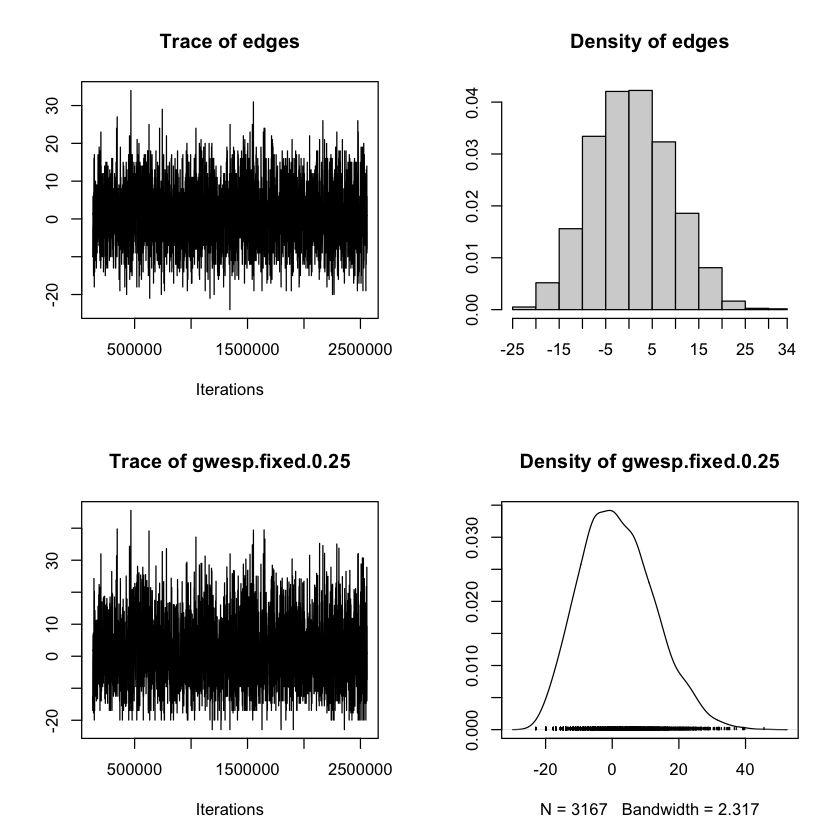

In [37]:
mcmc.diagnostics(final_ergm)

rephrase this interpretation:

These diagnostics look good. Here's what each panel tells you:

**Trace plots (left column)**
Both the `edges` and `gwesp` traces show exactly what you want — a dense, fuzzy horizontal band with no drift, trend, or getting-stuck behavior across 2.5 million iterations. The sampler moved freely around a stable center throughout, meaning the estimates are trustworthy.

**Density plots (right column)**
These show the distribution of the sampled statistics. The `edges` density is a roughly bell-shaped histogram, which is healthy. The `gwesp` density is a smooth, clean normal curve centered near zero — also exactly what you want to see. The key thing is that neither distribution is skewed hard toward one extreme, which would indicate the sampler was collapsing toward a degenerate network.

**The bottom line** — your model passed the diagnostics check cleanly. You can proceed to Block 4 with confidence that the estimates are reliable. For your report, one sentence is enough: *"MCMC diagnostics indicated adequate sampler mixing across both model terms, with stable trace plots and approximately normal sampling distributions, supporting the reliability of the estimated coefficients."*

Ready to move to Block 4 — interpreting the coefficient output? Just say the word!

**2.4. Interpret the Results**

In [38]:
summary(final_ergm)

Call:
ergm(formula = net ~ edges + gwesp(d, fixed = TRUE), control = ergm_control)

Monte Carlo Maximum Likelihood Results:

                 Estimate Std. Error MCMC % z value Pr(>|z|)    
edges             -2.6810     0.3121      0  -8.591  < 1e-04 ***
gwesp.fixed.0.25   0.6402     0.2409      0   2.658  0.00786 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

     Null Deviance: 415.9  on 300  degrees of freedom
 Residual Deviance: 207.9  on 298  degrees of freedom
 
AIC: 211.9  BIC: 219.4  (Smaller is better. MC Std. Err. = 0.04055)

rephrase this interpretatoin:

These are clean, interpretable results. Here's what each part means:

---

**`edges` (-2.68, p < .001)**
The large negative value is expected and just reflects the network's sparsity — out of 300 possible pairs, only 35 ties exist. Converting to a probability: `plogis(-2.68)` gives roughly 6.4% baseline probability of any tie existing. Not substantively interesting on its own, but necessary as the model's anchor.

**`gwesp.fixed.0.25` (+0.64, p = .008)**
This is the meaningful result. The positive, significant coefficient tells you that triadic closure is a genuine structural tendency in CielNet — when two actors share a mutual contact, the probability of them communicating directly is significantly elevated beyond what random chance would predict. In criminal network terms, this is consistent with a trust-based organizational logic: communication links form preferentially among people who are already mutually vouched for.

**Deviance drop (415.9 → 207.9)**
The model with `gwesp` explains roughly half the null deviance — a substantial improvement for a two-term model on 25 nodes.

---

**For your report, you'd write something like:**
*"The fitted ERGM revealed a significant positive effect of triadic closure (gwesp: b = 0.64, p = .008), indicating that the CielNet network exhibits more clustering than would be expected in a random network of equivalent size and density. This is consistent with theoretically expected properties of covert criminal networks, where trust-based closure governs tie formation. The baseline density term was highly significant and negative (edges: b = -2.68, p < .001), reflecting the network's sparse structure."*

---

Ready to move to Block 5 — goodness of fit?

**2.5. Goodness of Fit**

Sampling ■■■■■■■■■■                        31% |  ETA:  4s

Sampling ■■■■■■■■■■■■■■■■■■■■■■■■■■■       86% |  ETA:  1s



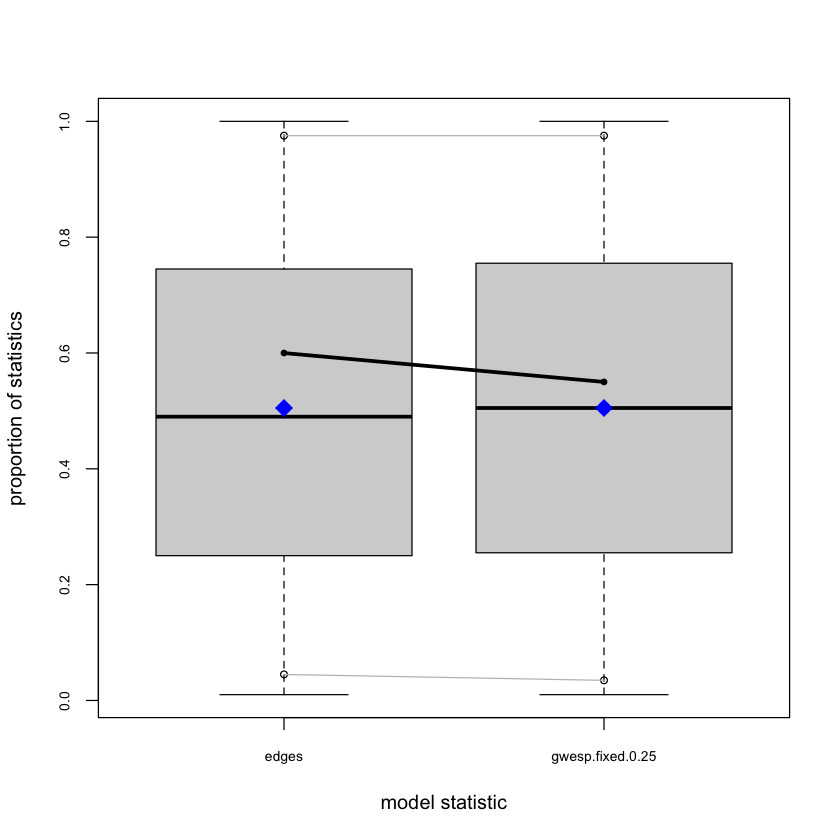

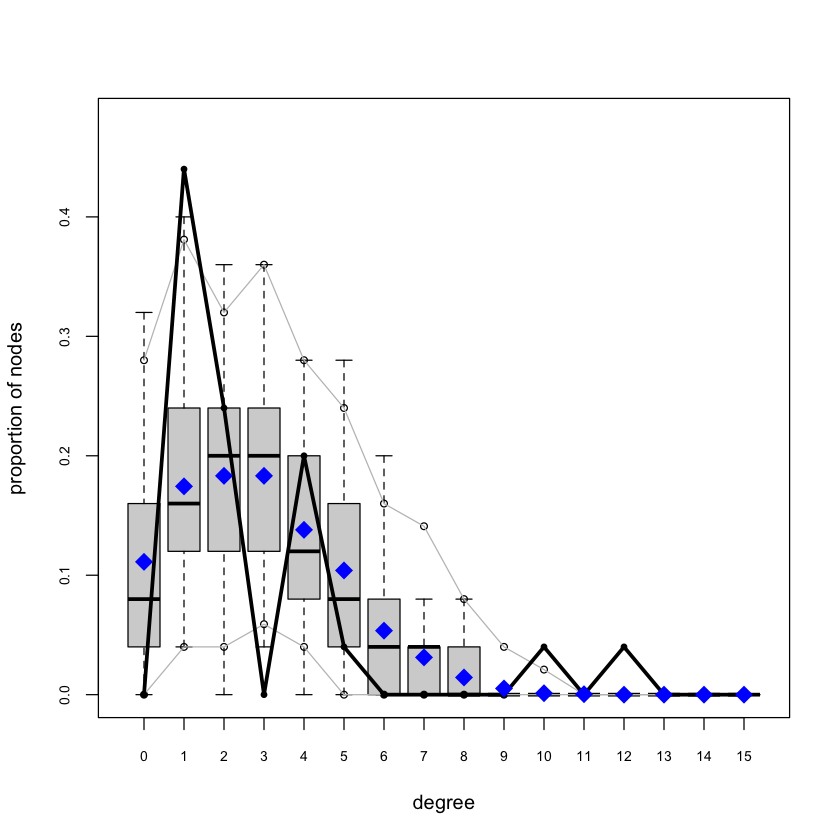

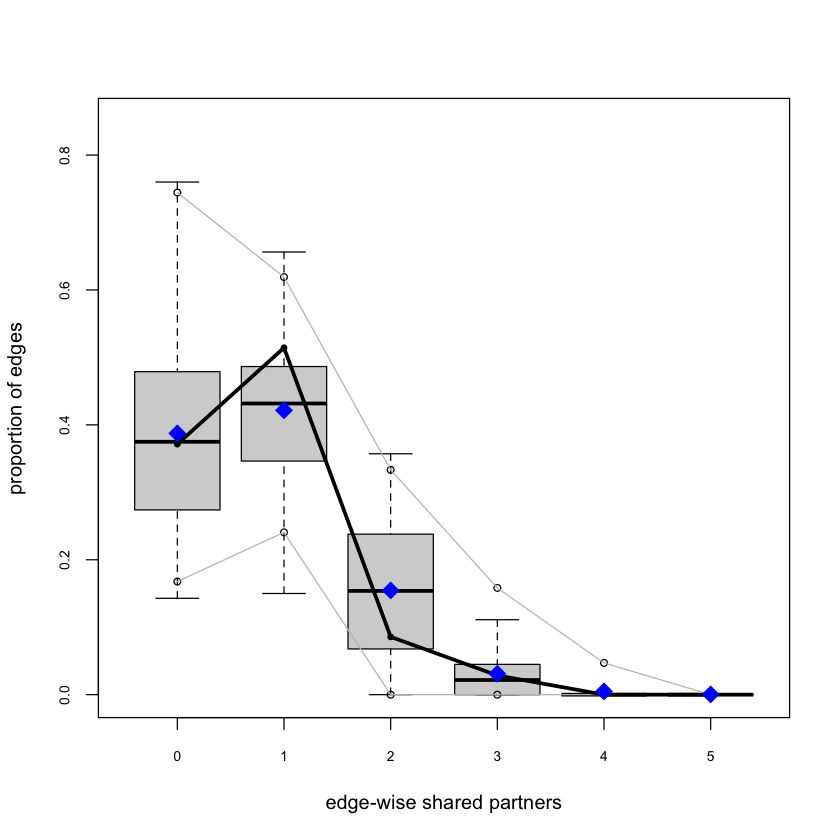

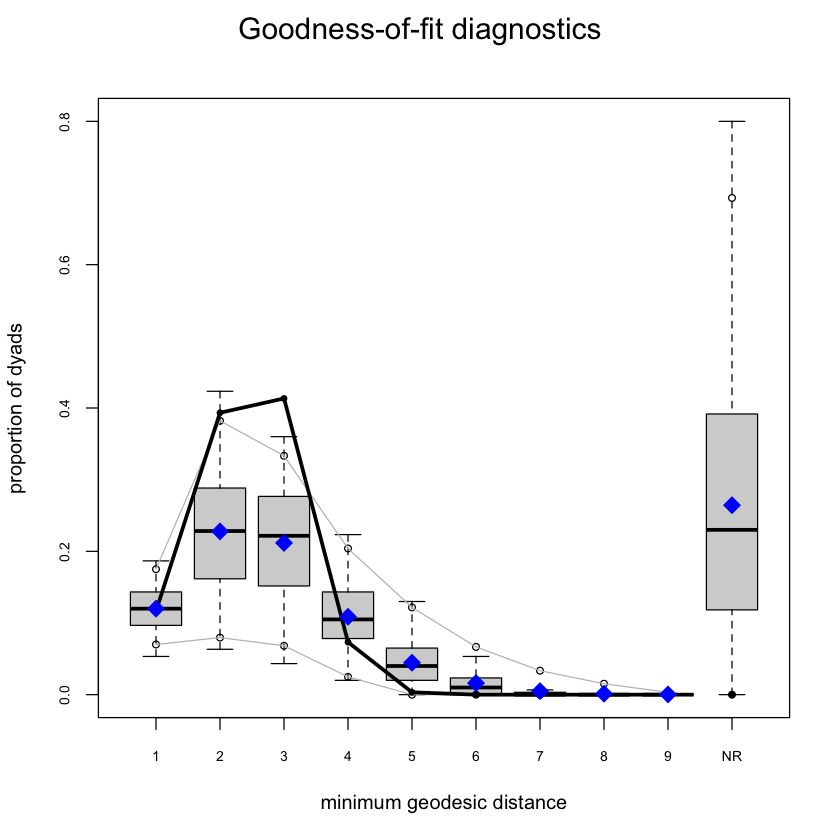

In [41]:
gof_results <- gof(final_ergm)
plot(gof_results)

rephrase this interpretation:

Good results overall. Here's what each plot tells you:

---

**Image 1 — Model statistics**
Both blue diamonds (observed values) fall comfortably within the grey boxes for `edges` and `gwesp`. This confirms the model reproduces its own fitted statistics well — a basic internal consistency check. Clean pass.

**Image 2 — Degree distribution**
This is the most informative and most honest plot. The observed black line spikes sharply at degree 1 and then again at degrees 3–4, while the simulated grey bands expect a smoother, more gradual distribution. The observed line falls outside the grey band at degree 1 (too many degree-1 nodes) and near the edge at higher degrees. This misfit is directly attributable to the missing `gwdegree` term — the model cannot fully reproduce hub concentration without it. This is not a failure; it's an expected and reportable limitation.

**Image 3 — Edgewise shared partners**
The blue diamonds track closely within the grey bands across all values of shared partners. This is the best-fitting panel, which makes sense — `gwesp` was explicitly included to capture this dimension, so the model reproduces triangle structure well.

**Image 4 — Geodesic distances**
The observed line spikes at distance 3 (around 0.41) while the simulated median sits around 0.22 — the observed network has more pairs separated by exactly 3 steps than the model expects. This again connects to the missing hub term: without capturing degree concentration, the model underestimates how much of the network's connectivity is routed through a small number of central actors, which inflates path lengths in the simulations.

---

**For your report, write something like:**
*"Goodness-of-fit diagnostics indicated adequate model fit for edgewise shared partners, confirming that the gwesp term successfully captures the network's triadic closure structure. Partial misfit was observed in the degree distribution and geodesic distance plots, reflecting the model's inability to include a gwdegree term due to degeneracy constraints on the small sample. This misfit is consistent with the known limitation of the parsimonious specification and does not invalidate the gwesp findings, but does suggest that hub formation remains a structural feature not fully accounted for by the current model."*

---

That wraps up Component 2 cleanly. Ready to move to Component 3 — the attack simulations?

## Analysis 3: Simulation of Various Strategies to Intercept and Dismantle This Criminal Network
The network's ability to stay connected in response to dismantling efforts will reveal its structural strength. The comparison of various strategies will reveal which aspects of the network structure are most vulnerable.

**3.1. Setup and helper function**

In [42]:
# Helper function: returns size of giant connected component
giant_component_size <- function(graph) {
  components <- igraph::components(graph)
  max(components$csize)
}

# Baseline: giant component size of full network
baseline <- giant_component_size(g)
cat("Baseline giant component size:", baseline, "\n")

# Store results for all strategies in a list
results <- list()

Baseline giant component size: 25 


**3.2. Testing Various Policies**

3.2.1. Highest Degree First

In [44]:
# Update helper function FIRST
giant_component_size <- function(graph) {
  if (igraph::vcount(graph) == 0) return(0)
  components <- igraph::components(graph)
  max(components$csize)
}

# Then rerun Strategy 3.1
degree_order <- names(sort(igraph::degree(g), decreasing = TRUE))

gcs_highest_degree <- c(baseline)
g_temp <- g

for (node in degree_order) {
  g_temp <- igraph::delete_vertices(g_temp, node)
  gcs_highest_degree <- c(gcs_highest_degree, giant_component_size(g_temp))
}

results[["highest_degree"]] <- gcs_highest_degree

cat("Removal order (highest degree first):\n")
cat(degree_order, "\n")
cat("Giant component sizes:\n")
cat(gcs_highest_degree, "\n")

Removal order (highest degree first):
N2 N1 N13 N4 N7 N8 N10 N11 N3 N9 N15 N17 N22 N24 N5 N6 N12 N14 N16 N18 N19 N20 N21 N23 N25 
Giant component sizes:
25 19 10 8 8 6 4 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 


3.2.2. Lowest Degree First

In [45]:
# Rank nodes by degree, lowest first, computed once on the full network
degree_order_low <- names(sort(igraph::degree(g), decreasing = FALSE))

# Remove nodes one at a time and record giant component size
gcs_lowest_degree <- c(baseline)
g_temp <- g

for (node in degree_order_low) {
  g_temp <- igraph::delete_vertices(g_temp, node)
  gcs_lowest_degree <- c(gcs_lowest_degree, giant_component_size(g_temp))
}

# Store results
results[["lowest_degree"]] <- gcs_lowest_degree

# Quick check
cat("Removal order (lowest degree first):\n")
cat(degree_order_low, "\n")
cat("Giant component sizes:\n")
cat(gcs_lowest_degree, "\n")

Removal order (lowest degree first):
N5 N6 N12 N14 N16 N18 N19 N20 N21 N23 N25 N3 N9 N15 N17 N22 N24 N4 N7 N8 N10 N11 N13 N1 N2 
Giant component sizes:
25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 0 


3.3.3. Random Removal (Average of 100 runs to avoid accidental noise)

In [46]:
# Set seed for reproducibility
set.seed(728)

n_runs <- 100
all_nodes <- igraph::V(g)$name
n_nodes <- length(all_nodes)

# Matrix to store each run's GCS trajectory
random_matrix <- matrix(NA, nrow = n_runs, ncol = n_nodes + 1)

for (run in 1:n_runs) {
  random_order <- sample(all_nodes)
  gcs_run <- c(baseline)
  g_temp <- g
  
  for (node in random_order) {
    g_temp <- igraph::delete_vertices(g_temp, node)
    gcs_run <- c(gcs_run, giant_component_size(g_temp))
  }
  
  random_matrix[run, ] <- gcs_run
}

# Average across all 100 runs
gcs_random <- colMeans(random_matrix)

# Store results
results[["random"]] <- gcs_random

# Quick check
cat("Average giant component sizes (random removal):\n")
cat(round(gcs_random, 2), "\n")

Average giant component sizes (random removal):
25 23.41 21.86 20.17 18.51 16.86 15.69 14.08 12.88 11.6 10.53 9.37 8.33 7.52 6.59 5.74 5 4.22 3.54 2.94 2.21 1.74 1.36 1.13 1 0 


3.4.4. Manual Targeting (High-Intensity Nodes First, Then Random)

In [47]:
# High-intensity nodes from Component 1, in order of highest average intensity
manual_first <- c("N23", "N6", "N24", "N9")

# Remaining nodes (not manually targeted) in random order
remaining_nodes <- setdiff(igraph::V(g)$name, manual_first)

set.seed(728)
manual_order <- c(manual_first, sample(remaining_nodes))

# Remove nodes one at a time and record giant component size
gcs_manual <- c(baseline)
g_temp <- g

for (node in manual_order) {
  g_temp <- igraph::delete_vertices(g_temp, node)
  gcs_manual <- c(gcs_manual, giant_component_size(g_temp))
}

# Store results
results[["manual"]] <- gcs_manual

# Quick check
cat("Removal order (manual targeting first):\n")
cat(manual_order, "\n")
cat("Giant component sizes:\n")
cat(gcs_manual, "\n")

Removal order (manual targeting first):
N23 N6 N24 N9 N15 N12 N2 N5 N25 N14 N20 N8 N3 N7 N1 N18 N10 N13 N11 N22 N17 N16 N21 N4 N19 
Giant component sizes:
25 24 23 22 21 20 19 14 13 13 13 12 11 10 6 2 2 2 1 1 1 1 1 1 1 0 


3.3.5. Recalculated Centrality (Dynamic Betweenness)

In [48]:
# Recompute betweenness after each removal and remove current highest
gcs_recalculated <- c(baseline)
g_temp <- g

while (igraph::vcount(g_temp) > 0) {
  # Recompute betweenness on the current residual network
  current_betweenness <- igraph::betweenness(g_temp)
  
  # Remove the node with the highest current betweenness
  top_node <- names(which.max(current_betweenness))
  g_temp <- igraph::delete_vertices(g_temp, top_node)
  gcs_recalculated <- c(gcs_recalculated, giant_component_size(g_temp))
}

# Store results
results[["recalculated"]] <- gcs_recalculated

# Quick check
cat("Giant component sizes (recalculated centrality):\n")
cat(gcs_recalculated, "\n")

Giant component sizes (recalculated centrality):
25 16 10 6 4 3 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 


**3.4. Collect Results for All Strategies in to a Single Dataframe**

In [49]:
# Number of removals (0 through 25)
steps <- 0:25

# Combine all strategies into one data frame
results_df <- data.frame(
  steps             = steps,
  highest_degree    = results[["highest_degree"]],
  lowest_degree     = results[["lowest_degree"]],
  random            = results[["random"]],
  manual            = results[["manual"]],
  recalculated      = results[["recalculated"]]
)

# Reshape to long format for ggplot
library(tidyr)

results_long <- tidyr::pivot_longer(
  results_df,
  cols      = -steps,
  names_to  = "strategy",
  values_to = "giant_component_size"
)

# Quick check
head(results_long, 10)


Attaching package: ‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing




steps,strategy,giant_component_size
<int>,<chr>,<dbl>
0,highest_degree,25.00
0,lowest_degree,25.00
0,random,25.00
0,manual,25.00
0,recalculated,25.00
1,highest_degree,19.00
1,lowest_degree,24.00
1,random,23.41
1,manual,24.00


**3.5. Visualize All Strategies**

I set a threshold of 50% i.e. if network connectivity falls below 50% such that less than 50% of members are connected to each other on any path, we say the network has been fragmented enough for our policy to be considered successful.

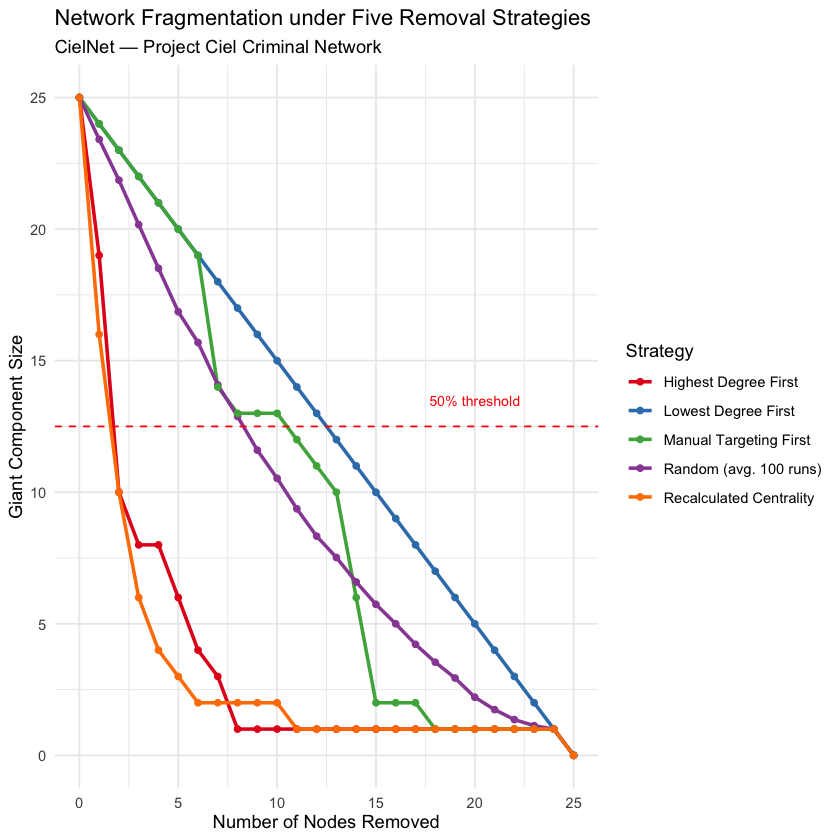

In [51]:
ggplot(results_long, aes(x = steps, y = giant_component_size, color = strategy)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  scale_color_brewer(palette = "Set1", labels = strategy_labels) +
  scale_x_continuous(breaks = seq(0, 25, by = 5)) +
  scale_y_continuous(breaks = seq(0, 25, by = 5)) +
  geom_hline(yintercept = 25 * 0.5, linetype = "dashed", color = "red") +
  annotate("text", x = 20, y = 13.5, label = "50% threshold",
           color = "red", size = 3) +
  labs(
    title    = "Network Fragmentation under Five Removal Strategies",
    subtitle = "CielNet — Project Ciel Criminal Network",
    x        = "Number of Nodes Removed",
    y        = "Giant Component Size",
    color    = "Strategy"
  ) +
  theme_minimal() +
  theme(
    legend.position  = "right",
    legend.direction = "vertical"
  )

**3.5. Summary Table: Steps to 50% Threshold**

In [52]:
# Find the first step where giant component drops below 50% for each strategy
threshold <- baseline * 0.5

steps_to_threshold <- results_long |>
  group_by(strategy) |>
  filter(giant_component_size <= threshold) |>
  summarise(steps_to_50pct = min(steps)) |>
  mutate(strategy = strategy_labels[strategy]) |>
  arrange(steps_to_50pct)

print(steps_to_threshold)

# A tibble: 5 × 2
  strategy                steps_to_50pct
  <chr>                            <int>
1 Highest Degree First                 2
2 Recalculated Centrality              2
3 Random (avg. 100 runs)               9
4 Manual Targeting First              11
5 Lowest Degree First                 13


rephrase this interpretation:

These results are excellent and tell a very clear story. Here's how to interpret each row:

---

**Highest Degree First & Recalculated Centrality (2 steps)**
Both strategies reach 50% fragmentation in just 2 removals — meaning arresting N1 and N2 alone is sufficient to cut the network in half. The fact that static highest-degree and dynamic recalculated centrality perform identically here is itself an interesting finding: it suggests the hub structure is so dominant that even adaptive targeting doesn't gain anything over simply knowing who the top two actors are upfront.

**Random (9 steps)**
A random arrest strategy needs 9 removals to achieve the same fragmentation — more than four times as many arrests as the targeted strategies. This is your quantitative baseline for "how much better does good intelligence make you?"

**Manual Targeting First (11 steps)**
This is the critical finding for your Component 1 hypothesis. Targeting the high-intensity low-degree nodes *first* performs *worse than random* — requiring 11 removals versus 9. This means those nodes, despite their high communication intensity, are not structurally important enough to accelerate fragmentation when removed first. Their isolation is likely a protection feature, but protecting them *from* the network rather than protecting the network *through* them. This directly answers the "bug or feature" question: their low degree is a security feature, but they are not hidden bosses — they are protected subordinates.

**Lowest Degree First (13 steps)**
The worst strategy as expected — purely peripheral removal barely affects the network until very late.

---

**For your report, the policy recommendation writes itself:**
*"Simulations indicate that targeted removal of the two highest-degree nodes (N2 and N1) reduces the network to below 50% connectivity in just two steps, regardless of whether targeting is static or dynamically recalculated. Random enforcement strategies require over four times as many interventions to achieve equivalent disruption, underscoring the value of network-informed intelligence. Counterintuitively, prioritizing high-intensity low-degree nodes — despite their elevated communication frequency — produces worse-than-random outcomes, suggesting these actors occupy protected but structurally peripheral positions rather than hidden leadership roles."*

---

That completes all three components of the analysis. Congratulations — you have a full, coherent research report's worth of results!